In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data.csv')

In [9]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [10]:
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [11]:
df.shape


(569, 33)

In [12]:
df.drop(["Unnamed: 32"],axis=1,inplace=True)

In [13]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [14]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
181,873593,M,21.090,26.57,142.70,1311.0,0.1141,0.28320,0.24870,0.14960,...,26.68,33.48,176.50,2089.0,0.1491,0.7584,0.6780,0.29030,0.4098,0.12840
394,903554,B,12.100,17.72,78.07,446.2,0.1029,0.09758,0.04783,0.03326,...,13.56,25.80,88.33,559.5,0.1432,0.1773,0.1603,0.06266,0.3049,0.07081
152,8710441,B,9.731,15.34,63.78,300.2,0.1072,0.15990,0.41080,0.07857,...,11.02,19.49,71.04,380.5,0.1292,0.2772,0.8216,0.15710,0.3108,0.12590
338,897880,B,10.050,17.53,64.41,310.8,0.1007,0.07326,0.02511,0.01775,...,11.16,26.84,71.98,384.0,0.1402,0.1402,0.1055,0.06499,0.2894,0.07664
531,91903901,B,11.670,20.02,75.21,416.2,0.1016,0.09453,0.04200,0.02157,...,13.35,28.81,87.00,550.6,0.1550,0.2964,0.2758,0.08120,0.3206,0.08950


In [15]:
df["diagnosis"]=df["diagnosis"].map({"M":1,"B":0})

In [16]:
df.sample(5)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
12,846226,1,19.170,24.80,132.40,1123.0,0.09740,0.24580,0.20650,0.11180,...,20.960,29.94,151.70,1332.0,0.1037,0.3903,0.36390,0.17670,0.3176,0.10230
310,893783,0,11.700,19.11,74.33,418.7,0.08814,0.05253,0.01583,0.01148,...,12.610,26.55,80.92,483.1,0.1223,0.1087,0.07915,0.05741,0.3487,0.06958
532,91903902,0,13.680,16.33,87.76,575.5,0.09277,0.07255,0.01752,0.01880,...,15.850,20.20,101.60,773.4,0.1264,0.1564,0.12060,0.08704,0.2806,0.07782
472,911384,0,14.920,14.93,96.45,686.9,0.08098,0.08549,0.05539,0.03221,...,17.180,18.22,112.00,906.6,0.1065,0.2791,0.31510,0.11470,0.2688,0.08273
358,9010333,0,8.878,15.49,56.74,241.0,0.08293,0.07698,0.04721,0.02381,...,9.981,17.70,65.27,302.0,0.1015,0.1248,0.09441,0.04762,0.2434,0.07431


<function matplotlib.pyplot.show(close=None, block=None)>

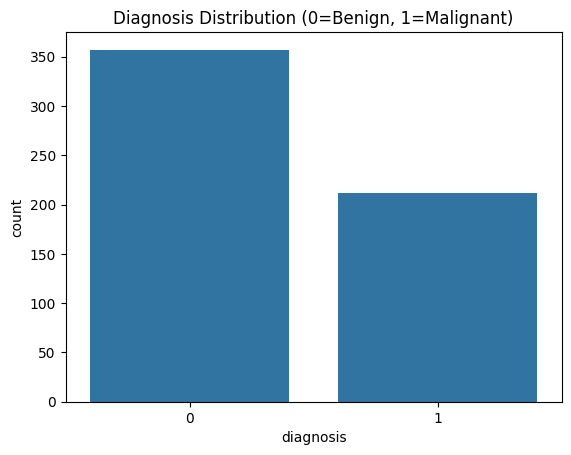

In [17]:
sns.countplot(x="diagnosis", data=df)
plt.title("Diagnosis Distribution (0=Benign, 1=Malignant)")
plt.show

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, roc_auc_score, roc_curve
)

<function matplotlib.pyplot.show(close=None, block=None)>

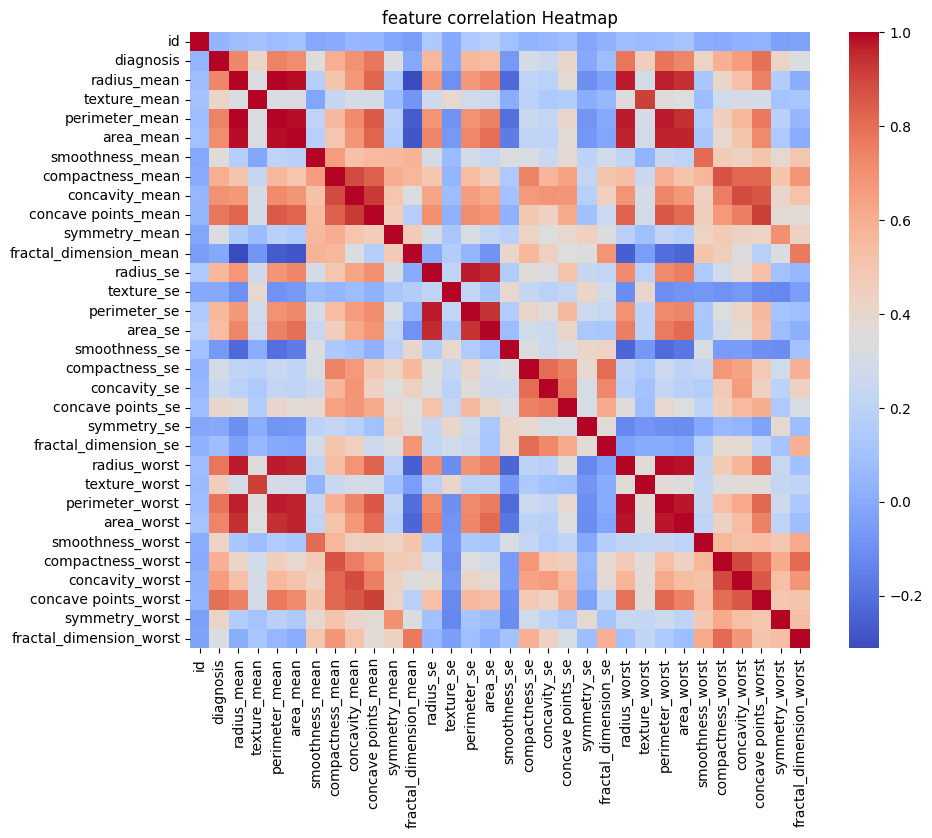

In [19]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("feature correlation Heatmap")
plt.show

In [21]:
x=df.drop("diagnosis",axis=1)
y=df["diagnosis"]

In [23]:
x_train, x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
x_train.shape,y_train.shape,x_test.shape


((455, 31), (455,), (114, 31))

In [24]:
pipeline =Pipeline(steps=[
    ('scalar',StandardScaler()),
    ('model',LogisticRegression(max_iter=1000))
])

In [25]:
pipeline.fit(x_train,y_train)

Pipeline(steps=[('scalar', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000))])

In [27]:
y_pred = pipeline.predict(x_test)
y_prob = pipeline.predict_proba(x_test)[:, 1]

In [28]:
y_pred

array([0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0,
       0, 0, 0, 1])

In [29]:
y_prob

array([3.60416734e-04, 9.99999989e-01, 4.19890431e-02, 5.70044266e-01,
       5.11128594e-01, 6.13419681e-04, 7.68374167e-01, 9.93952168e-04,
       5.77937026e-04, 9.97986666e-03, 9.26466014e-01, 6.91503361e-05,
       9.99999900e-01, 4.25971063e-03, 7.48260321e-03, 1.41395956e-06,
       6.27867855e-02, 3.75707642e-04, 2.24993218e-01, 4.77101807e-05,
       1.26402010e-03, 4.34209178e-03, 9.99999574e-01, 9.98343063e-01,
       7.57598005e-01, 2.00929990e-04, 1.66497129e-04, 9.68773753e-01,
       9.96838612e-01, 9.99593090e-01, 9.99991913e-01, 2.23550675e-03,
       9.99964081e-01, 9.99949549e-01, 2.64676788e-04, 1.34314991e-02,
       1.99468177e-03, 2.80455957e-06, 9.90882444e-01, 9.36933927e-02,
       1.06594705e-04, 3.30699164e-04, 8.48625251e-01, 2.46713969e-03,
       9.88380958e-03, 9.55476870e-01, 7.25015787e-02, 9.98386849e-01,
       5.95464243e-05, 1.07386365e-03, 9.99999992e-01, 9.98474240e-01,
       1.38711963e-02, 1.00338492e-03, 1.06727411e-04, 9.87655112e-01,
      

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9649122807017544


<function matplotlib.pyplot.show(close=None, block=None)>

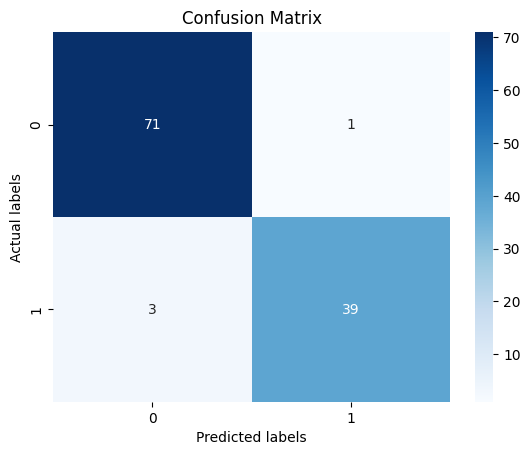

In [31]:
cm=confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted labels")
plt.ylabel("Actual labels")
plt.show


In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



ROC‑AUC Score: 0.996031746031746


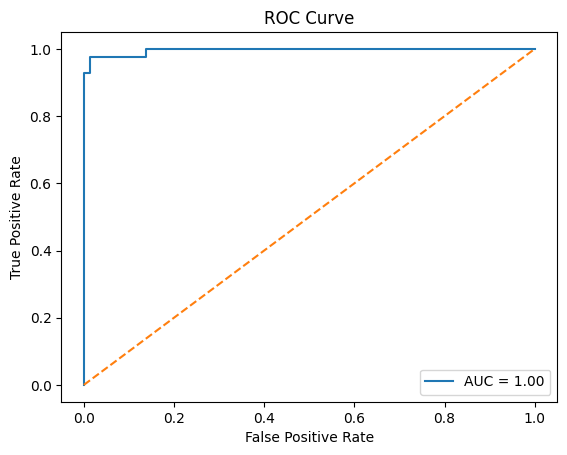

In [33]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC‑AUC Score:", roc_auc)

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [35]:
coefficients = pipeline.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": x.columns,
    "Coefficient": coefficients
}).sort_values(by="Coefficient", ascending=False)

feature_importance.head(10)

,Feature,Coefficient
22,texture_worst,1.428289
11,radius_se,1.245725
29,symmetry_worst,1.050745
8,concave points_mean,0.966908
27,concavity_worst,0.914354
14,area_se,0.906928
24,area_worst,0.893980
21,radius_worst,0.892894
7,concavity_mean,0.782857
13,perimeter_se,0.757171


In [36]:
import joblib

joblib.dump(pipeline, "cancer_model.pkl")

['cancer_model.pkl']

In [37]:
model = joblib.load("cancer_model.pkl")

In [39]:
import pandas as pd

new_data = pd.DataFrame([{
    "radius_mean": 14.5,
    "texture_mean": 20.1,
    "perimeter_mean": 95.0,
    "area_mean": 650.0,
      "texture_worst": 30.5,
    "symmetry_worst": 0.3
}])

In [43]:
new_data =x_test.iloc[[0]]

prediction = model.predict(new_data)
probability = model.predict_proba(new_data)[:, 1]

print("Prediction:", prediction)
print("Cancer Probability:", probability)

Prediction: [0]
Cancer Probability: [0.00036042]


In [44]:
import pandas as pd
import joblib

model = joblib.load("cancer_model.pkl")


expected_features = model.feature_names_in_

def predict_patient(data_dict):

    df = pd.DataFrame([data_dict])


    df = df.reindex(columns=expected_features, fill_value=0)

    pred = model.predict(df)[0]
    prob = model.predict_proba(df)[0][1]

    result = "Malignant (Cancer)" if pred == 1 else "Benign (Safe)"

    return {
        "prediction": result,
        "probability": round(prob, 4)
    }


sample = dict(zip(expected_features, [0]*len(expected_features)))
sample["texture_worst"] = 30
sample["radius_mean"] = 15

print(predict_patient(sample))


{'prediction': 'Benign (Safe)', 'probability': np.float64(0.0)}


In [45]:
from google.colab import files
files.download("cancer_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>